# FC-guided MoE on WikiText-2

这个 notebook 比较三种语言模型：Dense Transformer、常规 sparse MoE Transformer、以及由 Dense warmup 功能连接（FC）初始化的 FC-guided MoE Transformer。目标是在公平计算设置下观察 FC-guided MoE 是否能获得更低验证集 PPL。

## 1. 环境、配置和随机种子

主要超参数集中在这里。默认设置偏保守，但完整实验仍然需要 GPU；如果只是快速检查 notebook 是否能跑通，可以先把 `warmup_steps`、`moe_train_steps` 和 `eval_interval` 调小。

In [1]:
import os
import sys
import importlib
import math
import time
import random
import copy
from dataclasses import dataclass, asdict
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

# Reuse the tested v2.4 optimized FC construction and oracle-ridge initializer,
# while keeping this notebook's original model, baseline, training, and plots.
cwd = Path.cwd().resolve()
candidates = []
for base in (cwd, *cwd.parents):
    candidates.extend([base, base / 'experiments' / '08_transformer_moe'])
PACKAGE_DIR = next(
    (p for p in candidates if (p / '__init__.py').exists() and (p / 'methods.py').exists()),
    None,
)
if PACKAGE_DIR is None:
    raise RuntimeError('Cannot locate experiments/08_transformer_moe.')
if str(PACKAGE_DIR.parent) not in sys.path:
    sys.path.insert(0, str(PACKAGE_DIR.parent))
PACKAGE_NAME = PACKAGE_DIR.name
methods_module = importlib.import_module(f'{PACKAGE_NAME}.methods')
functional_hybrid_labels = methods_module.functional_hybrid_labels
_initialize_oracle_ridge_router = methods_module._initialize_oracle_ridge_router


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

@dataclass
class Config:
    data_dir: str = '/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2'
    seq_len: int = 128
    batch_size: int = 32
    vocab_min_freq: int = 1
    max_vocab_size: int = 5000
    d_model: int = 256
    n_heads: int = 4
    d_ff: int = 1024
    n_layers: int = 5
    num_experts: int = 4
    top_k: int = 1
    dropout: float = 0.1
    lr: float = 5e-4
    weight_decay: float = 0.01
    warmup_steps: int = 100
    moe_train_steps: int = 2000
    eval_interval: int = 20
    eval_batches: int = 30
    fc_batches: int = 50
    aux_loss_coef: float = 0.1
    fc_aux_loss_coef: float = 0.01
    grad_clip: float = 5.0
    log_interval: int = 20
    fc_consensus_splits: int = 4
    fc_output_weight: float = 0.35
    fc_uniform_shrinkage: float = 0.05
    fc_refinement_swaps: int = 64
    fc_hybrid_view_weights: tuple = ((1.00, 0.00, 0.00), (0.70, 0.15, 0.15),
                                     (0.55, 0.25, 0.20), (0.40, 0.30, 0.30))
    fc_oracle_tokens: int = 4096
    fc_router_ridge: float = 0.05
    fc_router_key_prior: float = 0.20
    router_calibration_temperature: float = 1.0
    fc_router_alignment_coef: float = 0.02
    fc_router_alignment_steps: int = 300


cfg = Config()
asdict(cfg)

device = cuda


{'data_dir': '/mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2',
 'seq_len': 128,
 'batch_size': 32,
 'vocab_min_freq': 1,
 'max_vocab_size': 5000,
 'd_model': 256,
 'n_heads': 4,
 'd_ff': 1024,
 'n_layers': 5,
 'num_experts': 4,
 'top_k': 1,
 'dropout': 0.1,
 'lr': 0.0005,
 'weight_decay': 0.01,
 'warmup_steps': 100,
 'moe_train_steps': 2000,
 'eval_interval': 20,
 'eval_batches': 30,
 'fc_batches': 50,
 'aux_loss_coef': 0.1,
 'fc_aux_loss_coef': 0.01,
 'grad_clip': 5.0,
 'log_interval': 20,
 'fc_consensus_splits': 4,
 'fc_output_weight': 0.35,
 'fc_uniform_shrinkage': 0.05,
 'fc_refinement_swaps': 64,
 'fc_hybrid_view_weights': ((1.0, 0.0, 0.0),
  (0.7, 0.15, 0.15),
  (0.55, 0.25, 0.2),
  (0.4, 0.3, 0.3)),
 'fc_oracle_tokens': 4096,
 'fc_router_ridge': 0.05,
 'fc_router_key_prior': 0.2,
 'router_calibration_temperature': 1.0,
 'fc_router_alignment_coef': 0.02,
 'fc_router_alignment_steps': 300}

## 2. 本地 WikiText-2 数据加载

这里只使用本地数据，不做 HuggingFace 下载回退。若路径不存在，请修改上一个单元里的 `cfg.data_dir`。

In [2]:
def load_data_local(data_dir):
    train_path = os.path.join(data_dir, 'wiki.train.tokens')
    val_path = os.path.join(data_dir, 'wiki.valid.tokens')
    if not os.path.exists(train_path) or not os.path.exists(val_path):
        raise FileNotFoundError(
            f'WikiText-2 files not found in {data_dir}. '
            'Please set cfg.data_dir to a directory containing wiki.train.tokens and wiki.valid.tokens.'
        )
    with open(train_path, 'r', encoding='utf-8') as f:
        train_text = f.read()
    with open(val_path, 'r', encoding='utf-8') as f:
        val_text = f.read()
    print(f'从本地加载 WikiText-2: {data_dir}')
    return train_text, val_text


def tokenize(text):
    return text.replace('\n', ' <eos> ').split()


def build_vocab(tokens, min_freq=1, max_vocab_size=50000):
    counts = defaultdict(int)
    for tok in tokens:
        counts[tok] += 1
    special_tokens = ['<pad>', '<unk>']
    vocab = list(special_tokens)
    seen = set(vocab)
    sorted_items = sorted(counts.items(), key=lambda x: (-x[1], x[0]))
    for tok, freq in sorted_items:
        if tok in seen:
            continue
        if freq < min_freq:
            continue
        if len(vocab) >= max_vocab_size:
            break
        vocab.append(tok)
        seen.add(tok)
    stoi = {tok: i for i, tok in enumerate(vocab)}
    itos = {i: tok for tok, i in stoi.items()}
    if len(stoi) != len(vocab) or max(stoi.values()) >= len(stoi):
        raise ValueError('Invalid vocabulary: duplicate tokens produced non-contiguous ids.')
    return stoi, itos


def encode(tokens, stoi):
    unk = stoi['<unk>']
    return torch.tensor([stoi.get(tok, unk) for tok in tokens], dtype=torch.long)


def validate_token_ids(name, ids, vocab_size):
    min_id = int(ids.min().item())
    max_id = int(ids.max().item())
    if min_id < 0 or max_id >= vocab_size:
        raise ValueError(
            f'{name} token ids out of range: min={min_id}, max={max_id}, vocab_size={vocab_size}. '
            'This would trigger a CUDA device-side assert in embedding or cross entropy.'
        )
    print(f'{name} token id range OK: [{min_id}, {max_id}] < vocab_size={vocab_size}')


class LMSequenceDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.token_ids = token_ids
        self.seq_len = seq_len
        self.n_seq = max(0, (len(token_ids) - 1) // seq_len)

    def __len__(self):
        return self.n_seq

    def __getitem__(self, idx):
        start = idx * self.seq_len
        x = self.token_ids[start:start + self.seq_len]
        y = self.token_ids[start + 1:start + self.seq_len + 1]
        return x, y


train_text, val_text = load_data_local(cfg.data_dir)
train_tokens = tokenize(train_text)
val_tokens = tokenize(val_text)
stoi, itos = build_vocab(train_tokens, cfg.vocab_min_freq, cfg.max_vocab_size)
vocab_size = len(stoi)
train_ids = encode(train_tokens, stoi)
val_ids = encode(val_tokens, stoi)
validate_token_ids('train_ids', train_ids, vocab_size)
validate_token_ids('val_ids', val_ids, vocab_size)

train_ds = LMSequenceDataset(train_ids, cfg.seq_len)
val_ds = LMSequenceDataset(val_ids, cfg.seq_len)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, drop_last=False)

print('vocab_size =', vocab_size)
print('train sequences =', len(train_ds), 'val sequences =', len(val_ds))

从本地加载 WikiText-2: /mnt/Data16T/Data/haichao/code/AI_connectom/story/story_part2_struc_func/Transformer/data/wikitext-2
train_ids token id range OK: [1, 4999] < vocab_size=5000
val_ids token id range OK: [1, 4998] < vocab_size=5000
vocab_size = 5000
train sequences = 16317 val sequences = 1700


## 3. 模型定义

Dense 模型使用 causal self-attention 和标准 FFN。MoE 模型只替换 FFN，attention 和残差结构保持一致，便于公平比较。

In [3]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.n_heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        if hasattr(F, 'scaled_dot_product_attention'):
            y = F.scaled_dot_product_attention(q, k, v, dropout_p=self.dropout.p if self.training else 0.0, is_causal=True)
        else:
            scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
            mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(mask, float('-inf'))
            attn = self.dropout(F.softmax(scores, dim=-1))
            y = attn @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(y)


class DenseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_hidden=False):
        hidden = F.gelu(self.fc1(x))
        out = self.fc2(self.dropout(hidden))
        if return_hidden:
            return out, hidden
        return out


class DenseBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = DenseFFN(d_model, d_ff, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, collect_ffn_hidden=False):
        x = x + self.dropout(self.attn(self.ln1(x)))
        ffn_in = self.ln2(x)
        if collect_ffn_hidden:
            ffn_out, hidden = self.ffn(ffn_in, return_hidden=True)
            x = x + self.dropout(ffn_out)
            return x, hidden
        x = x + self.dropout(self.ffn(ffn_in))
        return x, None


class TransformerLM(nn.Module):
    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.cfg = cfg
        self.token_emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.blocks = nn.ModuleList([
            DenseBlock(cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.dropout)
            for _ in range(cfg.n_layers)
        ])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, vocab_size, bias=False)
        self.dropout = nn.Dropout(cfg.dropout)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, collect_ffn_hidden=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.dropout(self.token_emb(x) + self.pos_emb(pos))
        hidden_by_layer = []
        for block in self.blocks:
            h, hidden = block(h, collect_ffn_hidden=collect_ffn_hidden)
            if collect_ffn_hidden:
                hidden_by_layer.append(hidden)
        logits = self.head(self.ln_f(h))
        if collect_ffn_hidden:
            return logits, hidden_by_layer
        return logits

    def get_layer_outputs(self, x):
        """
        获取输入序列在每一个 Dense 层的输出特征
        Returns: list of tensors, 每个 tensor 形状为 [B, T, d_model]
        """
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.dropout(self.token_emb(x) + self.pos_emb(pos))
        
        layer_outputs = []
        for block in self.blocks:
            # DenseBlock 返回 (x, hidden) 或 (x, None)，这里只需要提取模块输出 x (即更新后的 h)
            h, _ = block(h)
            layer_outputs.append(h)
            
        return layer_outputs


class ExpertFFN(nn.Module):
    def __init__(self, d_model, expert_d_ff, dropout, output_bias=True):
        super().__init__()
        self.fc1 = nn.Linear(d_model, expert_d_ff)
        self.fc2 = nn.Linear(expert_d_ff, d_model, bias=output_bias)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))


class SparseMoEFFN(nn.Module):
    def __init__(self, d_model, d_ff, num_experts, top_k, dropout, optimized_fc=False):
        super().__init__()
        assert d_ff % num_experts == 0, 'd_ff must be divisible by num_experts for matched active compute.'
        assert 1 <= top_k <= num_experts
        self.num_experts = num_experts
        self.top_k = top_k
        self.expert_d_ff = d_ff // num_experts
        self.optimized_fc = optimized_fc
        # The optimized FC model matches v2.4: bias-free linear router and
        # one shared dense-FFN output bias. The Regular MoE default is unchanged.
        self.router = nn.Linear(d_model, num_experts, bias=not optimized_fc)
        self.experts = nn.ModuleList([
            ExpertFFN(d_model, self.expert_d_ff, dropout, output_bias=not optimized_fc)
            for _ in range(num_experts)
        ])
        self.output_bias = nn.Parameter(torch.zeros(d_model)) if optimized_fc else None

    def forward(self, x):
        B, T, C = x.shape
        flat_x = x.reshape(B * T, C)
        router_logits = self.router(flat_x)
        router_probs = F.softmax(router_logits, dim=-1)
        top_probs, top_idx = torch.topk(router_probs, self.top_k, dim=-1)
        top_probs = top_probs / top_probs.sum(dim=-1, keepdim=True).clamp_min(1e-9)

        flat_out = torch.zeros_like(flat_x)
        for rank in range(self.top_k):
            idx = top_idx[:, rank]
            weight = top_probs[:, rank].unsqueeze(-1)
            for expert_id, expert in enumerate(self.experts):
                mask = idx == expert_id
                if mask.any():
                    flat_out[mask] += expert(flat_x[mask]) * weight[mask]

        if self.output_bias is not None:
            flat_out = flat_out + self.output_bias

        importance = router_probs.mean(dim=0)
        dispatch = F.one_hot(top_idx[:, 0], self.num_experts).float().mean(dim=0)
        aux_loss = self.num_experts * torch.sum(importance * dispatch)
        usage = dispatch.detach()
        return flat_out.view(B, T, C), aux_loss, usage

    def expert_targets(self, flat_x, target_kind='reconstruction_score'):
        outputs = []
        for expert in self.experts:
            hidden = F.gelu(expert.fc1(flat_x))
            outputs.append(F.linear(hidden, expert.fc2.weight, expert.fc2.bias))
        stacked = torch.stack(outputs, dim=1)
        if target_kind != 'reconstruction_score':
            raise ValueError(target_kind)
        dense_partition_output = stacked.sum(dim=1, keepdim=True)
        return -(stacked - dense_partition_output).square().mean(dim=-1)


class MoEBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, num_experts, top_k, dropout, optimized_fc=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.moe = SparseMoEFFN(d_model, d_ff, num_experts, top_k, dropout, optimized_fc=optimized_fc)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_pre_ffn=False):
        x = x + self.dropout(self.attn(self.ln1(x)))
        pre_ffn = self.ln2(x)
        moe_out, aux_loss, usage = self.moe(pre_ffn)
        x = x + self.dropout(moe_out)
        if return_pre_ffn:
            return x, aux_loss, usage, pre_ffn
        return x, aux_loss, usage


class MoETransformerLM(nn.Module):
    def __init__(self, vocab_size, cfg, optimized_fc=False):
        super().__init__()
        self.cfg = cfg
        self.token_emb = nn.Embedding(vocab_size, cfg.d_model, padding_idx=0)
        self.pos_emb = nn.Embedding(cfg.seq_len, cfg.d_model)
        self.blocks = nn.ModuleList([
            MoEBlock(cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.num_experts, cfg.top_k, cfg.dropout, optimized_fc=optimized_fc)
            for _ in range(cfg.n_layers)
        ])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, vocab_size, bias=False)
        self.dropout = nn.Dropout(cfg.dropout)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, x, return_pre_ffn=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.dropout(self.token_emb(x) + self.pos_emb(pos))
        aux_losses = []
        usages = []
        pre_ffn_by_layer = []
        for block in self.blocks:
            if return_pre_ffn:
                h, aux_loss, usage, pre_ffn = block(h, return_pre_ffn=True)
                pre_ffn_by_layer.append(pre_ffn)
            else:
                h, aux_loss, usage = block(h)
            aux_losses.append(aux_loss)
            usages.append(usage)
        logits = self.head(self.ln_f(h))
        aux_loss = torch.stack(aux_losses).mean()
        usage = torch.stack(usages).mean(dim=0)
        if return_pre_ffn:
            return logits, aux_loss, usage, pre_ffn_by_layer
        return logits, aux_loss, usage
    
    def get_layer_outputs(self, x):
        """
        获取输入序列在每一个 MoE 层的输出特征
        Returns: list of tensors, 每个 tensor 形状为 [B, T, d_model]
        """
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = self.dropout(self.token_emb(x) + self.pos_emb(pos))
        
        layer_outputs = []
        for block in self.blocks:
            # MoEBlock 返回 (out, aux_loss, usage)，这里只需要提取 out (即 h)
            h, _, _ = block(h)
            layer_outputs.append(h)
            
        return layer_outputs

## 4. 训练、评估和 FC 工具函数

FC-guided MoE 使用 dense FFN 的 hidden activations 构建稳定的 consensus FC，并联合输出贡献、正激活共现和 FFN key geometry。候选专家划分通过 top-1 dense-FFN 重建误差选择；router 使用 oracle-ridge 初始化。

In [4]:
def compute_fc(activations):
    """纯 GPU 计算 Pearson 相关功能连接矩阵"""
    FC = torch.corrcoef(activations.T)  # [d_model, d_model]
    FC = torch.nan_to_num(FC, nan=0.0, posinf=0.0, neginf=0.0)
    return FC

def get_top_ratio_fc_mean(fc_matrix, ratio=0.05):
    """获取矩阵中非对角线最大前 ratio (默认 5%) 个值的平均值"""
    d = fc_matrix.size(0)
    
    # 过滤掉对角线上的自相关值 (永远为 1.0)
    mask = ~torch.eye(d, dtype=torch.bool, device=fc_matrix.device)
    vals = fc_matrix.abs()[mask]
    
    # 动态计算 Top-5% 对应的实际数量 k
    # 使用 max(1, ...) 确保即使矩阵很小，也至少提取 1 个值
    actual_k = max(1, int(vals.numel() * ratio))
    
    # 提取 Top-k
    topk_vals = torch.topk(vals, actual_k).values
    return topk_vals.mean().item()

@torch.no_grad()
def track_training_fc(model, data_loader, n_samples=160, device='cuda', fc_method='concat'):
    """
    在单次前向传播中收集所有层的激活值，并计算各层的平均 Top-5 FC，最后返回全模型的整体平均值。
    """
    model.eval()
    collected = 0
    all_acts_by_layer = [[] for _ in range(len(model.blocks))]

    for x, _ in data_loader:
        if collected >= n_samples:
            break
            
        current_batch_size = min(x.shape[0], n_samples - collected)
        x = x[:current_batch_size].to(device)

        # 获取所有层的输出列表
        layer_outputs = model.get_layer_outputs(x)

        for l_idx, h_out in enumerate(layer_outputs):
            if fc_method == 'mean':
                neuron_out = h_out.mean(dim=1)
            elif fc_method == 'concat':
                neuron_out = h_out.reshape(-1, h_out.shape[-1])
            else:
                raise ValueError("不支持的FC计算方法")
                
            all_acts_by_layer[l_idx].append(neuron_out)

        collected += current_batch_size

    # 计算并汇总每一层的 Top-5 FC 均值
    layer_fc_means = []
    for l_acts in all_acts_by_layer:
        acts = torch.cat(l_acts, dim=0)  # 'mean': [N, d], 'concat': [N*T, d]
        fc_matrix = compute_fc(acts)
        layer_top5_mean = get_top_ratio_fc_mean(fc_matrix, ratio=0.05)
        layer_fc_means.append(layer_top5_mean)

    # 返回所有 Transformer 层的 Top-5 FC 的全局平均值
    return np.mean(layer_fc_means)


def get_batch_iterator(loader):
    while True:
        for batch in loader:
            yield batch


def lm_loss_from_logits(logits, y):
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1), ignore_index=0)


def check_batch_ids(x, y, vocab_size, seq_len, where):
    if x.dtype != torch.long or y.dtype != torch.long:
        raise TypeError(f'{where}: x/y must be torch.long, got {x.dtype}/{y.dtype}')
    if x.ndim != 2 or y.ndim != 2:
        raise ValueError(f'{where}: x/y must be [B, T], got {tuple(x.shape)} / {tuple(y.shape)}')
    if x.size(1) > seq_len or y.size(1) > seq_len:
        raise ValueError(f'{where}: sequence length exceeds cfg.seq_len={seq_len}: {x.size(1)} / {y.size(1)}')
    x_min, x_max = int(x.min().item()), int(x.max().item())
    y_min, y_max = int(y.min().item()), int(y.max().item())
    if x_min < 0 or y_min < 0 or x_max >= vocab_size or y_max >= vocab_size:
        raise ValueError(
            f'{where}: token ids out of range. '
            f'x=[{x_min}, {x_max}], y=[{y_min}, {y_max}], vocab_size={vocab_size}'
        )


@torch.no_grad()
def evaluate_dense(model, loader, max_batches=30):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        check_batch_ids(x, y, model.head.out_features, model.cfg.seq_len, 'evaluate_dense')
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = lm_loss_from_logits(logits, y)
        losses.append(loss.item())
    mean_loss = float(np.mean(losses))
    return mean_loss, math.exp(min(mean_loss, 20))


# @torch.no_grad()
# def evaluate_moe(model, loader, max_batches=30):
#     model.eval()
#     losses = []
#     usages = []
#     for i, (x, y) in enumerate(loader):
#         if i >= max_batches:
#             break
#         check_batch_ids(x, y, model.head.out_features, model.cfg.seq_len, 'evaluate_moe')
#         x, y = x.to(device), y.to(device)
#         logits, aux_loss, usage = model(x)
#         loss = lm_loss_from_logits(logits, y)
#         losses.append(loss.item())
#         usages.append(usage.cpu())
#     mean_loss = float(np.mean(losses))
#     mean_usage = torch.stack(usages).mean(dim=0).numpy() if usages else None
#     return mean_loss, math.exp(min(mean_loss, 20)), mean_usage

@torch.no_grad()
def evaluate_moe(model, loader, max_batches=30):
    model.eval()
    # losses = []
    usages = []
    total_loss = 0.0
    total_tokens = 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        check_batch_ids(x, y, model.head.out_features, model.cfg.seq_len, 'evaluate_moe')
        x, y = x.to(device), y.to(device)
        logits, aux_loss, usage = model(x)
        loss = lm_loss_from_logits(logits, y)
        total_loss += loss.item() * y.numel()
        total_tokens += y.numel()
        # losses.append(loss.item())
        usages.append(usage.cpu())
    mean_loss = float(total_loss / total_tokens) if total_tokens > 0 else 0
    mean_usage = torch.stack(usages).mean(dim=0).numpy() if usages else None
    return mean_loss, math.exp(min(mean_loss, 20)), mean_usage


def train_dense(model, train_loader, val_loader, steps, name='dense'):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    it = get_batch_iterator(train_loader)
    
    # 1. 在 history 字典中增加 'fc_top_mean' 列表
    history = {'step': [], 'train_loss': [], 'val_loss': [], 'val_ppl': [], 'seconds': [], 'fc_top_mean': []}
    start_time = time.time()
    
    # ================= 2. 新增：第 0 步（初始随机状态）评估 =================
    # print(f"[{name}] 开始评估初始状态 (Step 0)...")
    # model.eval()
    # val_loss, val_ppl = evaluate_dense(model, val_loader, cfg.eval_batches)
    # # 调用通用的提取函数记录第0步的FC
    # fc_top5 = track_training_fc(model, val_loader, n_samples=cfg.batch_size * 5, device=device)
    
    # history['step'].append(0)
    # history['train_loss'].append(val_loss) # 占位，保证列表长度一致
    # history['val_loss'].append(val_loss)
    # history['val_ppl'].append(val_ppl)
    # history['seconds'].append(0.0)
    # history['fc_top_mean'].append(fc_top5)
    # print(f'[{name}] eval step    0 val_loss={val_loss:.4f} val_ppl={val_ppl:.2f} fc_top_mean={fc_top5:.4f}')
    # ===================================================================

    model.train()
    
    # 开始正式训练循环
    for step in range(1, steps + 1):
        x, y = next(it)
        check_batch_ids(x, y, model.head.out_features, model.cfg.seq_len, f'{name} step {step}')
        x, y = x.to(device), y.to(device)
        
        logits = model(x)
        loss = lm_loss_from_logits(logits, y)
        
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        if step % cfg.log_interval == 0:
            print(f'[{name}] step {step:4d} lm_loss={loss.item():.4f}')
            
        if step % cfg.eval_interval == 0 or step == steps:
            val_loss, val_ppl = evaluate_dense(model, val_loader, cfg.eval_batches)
            
            # ================= 3. 新增：记录当前 step 的 FC =================
            fc_top5 = track_training_fc(model, val_loader, n_samples=cfg.batch_size, device=device)
            # ================================================================
            
            history['step'].append(step)
            history['train_loss'].append(loss.item())
            history['val_loss'].append(val_loss)
            history['val_ppl'].append(val_ppl)
            history['seconds'].append(time.time() - start_time)
            history['fc_top_mean'].append(fc_top5) # 存入历史记录
            
            print(f'[{name}] eval step {step:4d} val_loss={val_loss:.4f} val_ppl={val_ppl:.2f} fc_top_mean={fc_top5:.4f}')
            model.train()
            
    return history


def joint_reconstruction_alignment_loss(model, pre_ffn_by_layer):
    losses = []
    temperature = cfg.router_calibration_temperature
    for layer_idx, block in enumerate(model.blocks):
        flat_x = pre_ffn_by_layer[layer_idx].detach().reshape(-1, cfg.d_model)
        with torch.no_grad():
            target = block.moe.expert_targets(flat_x, 'reconstruction_score')
            centered = target - target.mean(dim=-1, keepdim=True)
            scale = centered.std(dim=-1, unbiased=False, keepdim=True).clamp_min(1e-6)
            target_probability = F.softmax(centered / scale / temperature, dim=-1)
        prediction_log_probability = F.log_softmax(block.moe.router(flat_x) / temperature, dim=-1)
        losses.append(F.kl_div(
            prediction_log_probability, target_probability, reduction='batchmean'
        ) * temperature ** 2)
    return torch.stack(losses).mean()


def train_moe(model, train_loader, val_loader, steps, name='moe',
              joint_router_alignment=False, aux_loss_coef=None):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    it = get_batch_iterator(train_loader)
    history = {'step': [], 'train_loss': [], 'val_loss': [], 'val_ppl': [], 'seconds': [],
               'usage': [], 'fc_top_mean': [], 'router_alignment_loss': []}
    start_time = time.time()
    effective_aux_coef = cfg.aux_loss_coef if aux_loss_coef is None else aux_loss_coef

    # print(f'[{name}] 开始评估初始状态 (Step 0)...')
    # model.eval()
    # val_loss, val_ppl, val_usage = evaluate_moe(model, val_loader, cfg.eval_batches)
    # fc_top_mean = track_training_fc(model, val_loader, n_samples=cfg.batch_size * 5, device=device)
    
    # history['step'].append(0)
    # history['train_loss'].append(val_loss) # 占位，保证列表长度一致
    # history['val_loss'].append(val_loss)
    # history['val_ppl'].append(val_ppl)
    # history['seconds'].append(0.0)
    # history['usage'].append(val_usage)
    # history['fc_top_mean'].append(fc_top_mean)
    # print(f'[{name}] eval step    0 val_loss={val_loss:.4f} val_ppl={val_ppl:.2f} usage={val_usage} fc_top_mean={fc_top_mean:.4f}')

    model.train()
    for step in range(1, steps + 1):
        x, y = next(it)
        check_batch_ids(x, y, model.head.out_features, model.cfg.seq_len, f'train_moe step {step}')
        x, y = x.to(device), y.to(device)
        if joint_router_alignment and step <= cfg.fc_router_alignment_steps:
            logits, aux_loss, usage, pre_ffn_by_layer = model(x, return_pre_ffn=True)
            router_alignment_loss = joint_reconstruction_alignment_loss(model, pre_ffn_by_layer)
        else:
            logits, aux_loss, usage = model(x)
            router_alignment_loss = logits.new_zeros(())
        lm_loss = lm_loss_from_logits(logits, y)
        loss = lm_loss + effective_aux_coef * aux_loss
        if joint_router_alignment and step <= cfg.fc_router_alignment_steps:
            loss = loss + cfg.fc_router_alignment_coef * router_alignment_loss
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step()

        if step % cfg.log_interval == 0:
            print(f'[{name}] step {step:4d} lm_loss={lm_loss.item():.4f} aux={aux_loss.item():.4f} align={router_alignment_loss.item():.4f} usage={usage.cpu().numpy()}')
        if step % cfg.eval_interval == 0 or step == steps:
            val_loss, val_ppl, val_usage = evaluate_moe(model, val_loader, cfg.eval_batches)
            fc_top_mean = track_training_fc(model, val_loader, n_samples=cfg.batch_size, device=device)
            history['step'].append(step)
            history['train_loss'].append(lm_loss.item())
            history['val_loss'].append(val_loss)
            history['val_ppl'].append(val_ppl)
            history['seconds'].append(time.time() - start_time)
            history['usage'].append(val_usage)
            history['fc_top_mean'].append(fc_top_mean)
            history['router_alignment_loss'].append(router_alignment_loss.item())
            print(f'[{name}] eval step {step:4d} val_loss={val_loss:.4f} val_ppl={val_ppl:.2f} usage={val_usage} fc_top_mean={fc_top_mean:.4f}')
            model.train()
    return history


@torch.no_grad()
def collect_ffn_calibration_cache(model, loader, max_batches=50, max_tokens_per_batch=512, seed=60042):
    model.eval()
    pre_ffn_by_layer = [[] for _ in range(cfg.n_layers)]
    hidden_by_layer = [[] for _ in range(cfg.n_layers)]
    generator = torch.Generator(device='cpu').manual_seed(seed)
    for batch_idx, (x, _) in enumerate(loader):
        if batch_idx >= max_batches:
            break
        x = x.to(device)
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        h = model.dropout(model.token_emb(x) + model.pos_emb(pos))
        for layer_idx, block in enumerate(model.blocks):
            h = h + block.dropout(block.attn(block.ln1(h)))
            pre_ffn = block.ln2(h)
            ffn_out, hidden = block.ffn(pre_ffn, return_hidden=True)
            h = h + block.dropout(ffn_out)
            pre_flat = pre_ffn.reshape(-1, pre_ffn.size(-1)).float().cpu()
            hidden_flat = hidden.reshape(-1, hidden.size(-1)).float().cpu()
            count = min(max_tokens_per_batch, pre_flat.size(0))
            indices = torch.randperm(pre_flat.size(0), generator=generator)[:count]
            pre_ffn_by_layer[layer_idx].append(pre_flat[indices])
            hidden_by_layer[layer_idx].append(hidden_flat[indices])
    if not pre_ffn_by_layer[0]:
        raise ValueError('No dense calibration activations were collected')
    return (
        [torch.cat(parts, dim=0) for parts in pre_ffn_by_layer],
        [torch.cat(parts, dim=0) for parts in hidden_by_layer],
    )


def compute_fc(activations):
    x = activations.to(device)
    x = x - x.mean(dim=0, keepdim=True)
    x = x / x.std(dim=0, keepdim=True).clamp_min(1e-6)
    fc = torch.corrcoef(x.T)
    fc = torch.nan_to_num(fc, nan=0.0, posinf=0.0, neginf=0.0)
    return fc.cpu()


def topk_fc_mean(fc, frac=0.30):
    d = fc.size(0)
    mask = ~torch.eye(d, dtype=torch.bool)
    vals = fc.abs()[mask]
    k = max(1, int(vals.numel() * frac))
    return torch.topk(vals, k).values.mean().item()

## 5. 优化后的 FC-guided MoE 构造和初始化

FC-guided MoE 根据多视图功能图构造等宽专家，复制对应的 `fc1` 行和 `fc2` 列，保留共享输出偏置，并使用最优 top-1 重建专家拟合 ridge router。Regular MoE 保持原来的随机初始化 baseline；二者总训练预算不变。

In [5]:
def copy_dense_common_weights(dense_model, moe_model):
    moe_model.token_emb.weight.data.copy_(dense_model.token_emb.weight.data)
    moe_model.pos_emb.weight.data.copy_(dense_model.pos_emb.weight.data)
    moe_model.ln_f.weight.data.copy_(dense_model.ln_f.weight.data)
    moe_model.ln_f.bias.data.copy_(dense_model.ln_f.bias.data)
    moe_model.head.weight.data.copy_(dense_model.head.weight.data)
    for dense_block, moe_block in zip(dense_model.blocks, moe_model.blocks):
        moe_block.ln1.load_state_dict(dense_block.ln1.state_dict())
        moe_block.attn.load_state_dict(dense_block.attn.state_dict())
        moe_block.ln2.load_state_dict(dense_block.ln2.state_dict())


def init_regular_moe_from_dense(dense_model, moe_model):
    copy_dense_common_weights(dense_model, moe_model)
    # Regular MoE 只共享 embedding/attention/head，专家保持随机初始化。
    return moe_model


def init_fc_guided_moe_from_dense(dense_model, moe_model, pre_ffn_acts, ffn_acts):
    """Initialize the optimized FC-guided MoE while leaving the baseline unchanged."""
    copy_dense_common_weights(dense_model, moe_model)
    expert_size = cfg.d_ff // cfg.num_experts
    clusters_by_layer = []
    construction_diagnostics = []
    with torch.no_grad():
        for layer_idx, (dense_block, moe_block) in enumerate(zip(dense_model.blocks, moe_model.blocks)):
            labels, diagnostics = functional_hybrid_labels(
                ffn_acts[layer_idx],
                dense_block.ffn.fc1.weight,
                dense_block.ffn.fc2.weight,
                cfg.num_experts,
                seed=42 + layer_idx,
                cfg=cfg,
            )
            clusters = [
                torch.nonzero(labels == expert_id, as_tuple=False).squeeze(-1).tolist()
                for expert_id in range(cfg.num_experts)
            ]
            if any(len(group) != expert_size for group in clusters):
                raise ValueError(f'Layer {layer_idx}: FC construction is not exactly balanced')
            clusters_by_layer.append(clusters)
            for expert_id, unit_idx in enumerate(clusters):
                idx = torch.tensor(unit_idx, dtype=torch.long, device=dense_block.ffn.fc1.weight.device)
                expert = moe_block.moe.experts[expert_id]
                expert.fc1.weight.data.copy_(dense_block.ffn.fc1.weight.data[idx])
                expert.fc1.bias.data.copy_(dense_block.ffn.fc1.bias.data[idx])
                expert.fc2.weight.data.copy_(dense_block.ffn.fc2.weight.data[:, idx])
            if moe_block.moe.output_bias is None:
                raise RuntimeError('Optimized FC-guided MoE requires a shared output bias')
            moe_block.moe.output_bias.data.copy_(dense_block.ffn.fc2.bias.data)
            router_diagnostics = _initialize_oracle_ridge_router(
                moe_block.moe,
                pre_ffn_acts[layer_idx],
                ffn_acts[layer_idx],
                dense_block.ffn.fc1.weight,
                dense_block.ffn.fc2.weight,
                labels,
                cfg,
            )
            layer_diagnostics = {
                'layer': layer_idx,
                'selected_strategy': diagnostics['selected_strategy'],
                'selected_weights': diagnostics['selected_weights'],
                'oracle_normalized_mse': diagnostics['oracle_normalized_mse'],
                'oracle_usage_entropy': diagnostics['oracle_usage_entropy'],
                'ridge_accuracy': router_diagnostics['ridge_accuracy'],
                'refinement_accepted': diagnostics['refinement_accepted'],
            }
            construction_diagnostics.append(layer_diagnostics)
            print('FC-guided layer diagnostics:', layer_diagnostics)
    return moe_model, clusters_by_layer, construction_diagnostics


def estimate_active_ffn_params(cfg):
    dense_ffn = cfg.n_layers * (cfg.d_model * cfg.d_ff + cfg.d_ff + cfg.d_ff * cfg.d_model + cfg.d_model)
    expert_d_ff = cfg.d_ff // cfg.num_experts
    active_moe_ffn = cfg.n_layers * cfg.top_k * (cfg.d_model * expert_d_ff + expert_d_ff + expert_d_ff * cfg.d_model + cfg.d_model)
    router = cfg.n_layers * (cfg.d_model * cfg.num_experts + cfg.num_experts)
    return dense_ffn, active_moe_ffn + router


dense_active, moe_active = estimate_active_ffn_params(cfg)
print('Dense active FFN params per token:', dense_active)
print('MoE active FFN+router params per token:', moe_active)
print('Active ratio:', moe_active / dense_active)

Dense active FFN params per token: 2627840
MoE active FFN+router params per token: 663060
Active ratio: 0.252321298100341


## 6. Dense warmup 和 FC 提取

先训练 dense 模型，让表示完成早期组织；随后提取每层 FFN hidden activation 的 FC，并记录 top 30% FC mean。

In [6]:
seed_everything(42)
dense_model = TransformerLM(vocab_size, cfg)
dense_history = train_dense(dense_model, train_loader, val_loader, cfg.warmup_steps, name='dense-warmup')

pre_ffn_acts, ffn_acts = collect_ffn_calibration_cache(
    dense_model, train_loader, cfg.fc_batches, max_tokens_per_batch=512, seed=60042
)
fc_mats = [compute_fc(acts) for acts in ffn_acts]
fc_top30 = [topk_fc_mean(fc, frac=0.30) for fc in fc_mats]
print('Top 30% FC mean by layer:', fc_top30)

[dense-warmup] step   20 lm_loss=5.9921
[dense-warmup] eval step   20 val_loss=5.9661 val_ppl=390.00 fc_top_mean=0.6002
[dense-warmup] step   40 lm_loss=5.7164
[dense-warmup] eval step   40 val_loss=5.6396 val_ppl=281.34 fc_top_mean=0.6779
[dense-warmup] step   60 lm_loss=5.6552
[dense-warmup] eval step   60 val_loss=5.5890 val_ppl=267.48 fc_top_mean=0.9360
[dense-warmup] step   80 lm_loss=5.5000
[dense-warmup] eval step   80 val_loss=5.4067 val_ppl=222.89 fc_top_mean=0.9368
[dense-warmup] step  100 lm_loss=5.3122
[dense-warmup] eval step  100 val_loss=5.2340 val_ppl=187.53 fc_top_mean=0.9391
Top 30% FC mean by layer: [0.6893911957740784, 0.7425481677055359, 0.7428883910179138, 0.7448064088821411, 0.753487229347229]


## 7. 训练 Regular MoE 与 FC-guided MoE

Regular MoE 保持原始随机初始化 baseline。FC-guided MoE 继承 dense warmup 的共享部分和多视图 FC 专家，并在前 300 个 MoE step 使用重建目标对齐 router；两者采用相同的总优化步数预算。

In [7]:
# ==========================================
# 1. 训练 Regular MoE (完全从头随机初始化)
# ==========================================
seed_everything(123)
regular_moe = MoETransformerLM(vocab_size, cfg)

# 取消调用 init_regular_moe_from_dense，保持模型原本的随机初始化状态
# 直接训练 2500 步 (cfg.moe_train_steps)
regular_history = train_moe(regular_moe, train_loader, val_loader, cfg.moe_train_steps, name='regular-moe')

# ==========================================
# 2. 训练 FC-guided MoE（继承 Dense，并使用优化后的功能专家与 ridge router 初始化）
# ==========================================
seed_everything(123)
fc_guided_moe = MoETransformerLM(vocab_size, cfg, optimized_fc=True)
fc_guided_moe, clusters_by_layer, fc_guided_diagnostics = init_fc_guided_moe_from_dense(
    dense_model, fc_guided_moe, pre_ffn_acts, ffn_acts
)

# 计算剩余的训练步数 (2500步 - 300步 = 2200步)
fc_train_steps = cfg.moe_train_steps - cfg.warmup_steps
fc_guided_history = train_moe(
    fc_guided_moe, train_loader, val_loader, fc_train_steps,
    name='FC-guided MoE', joint_router_alignment=True, aux_loss_coef=cfg.fc_aux_loss_coef
)

# 为了保证后续画图的可视化对齐，将 FC-guided MoE 的历史步数整体平移预热步数
fc_guided_history['step'] = [s + cfg.warmup_steps for s in fc_guided_history['step']]

[regular-moe] step   20 lm_loss=6.0027 aux=1.0276 align=0.0000 usage=[0.31088868 0.25551757 0.2154297  0.21816407]
[regular-moe] eval step   20 val_loss=5.9098 val_ppl=368.63 usage=[0.41502604 0.35703614 0.0876774  0.14026041] fc_top_mean=0.7458
[regular-moe] step   40 lm_loss=5.6162 aux=1.0249 align=0.0000 usage=[0.23505859 0.1977539  0.2761719  0.29101562]
[regular-moe] eval step   40 val_loss=5.6469 val_ppl=283.41 usage=[0.23336591 0.16431803 0.26526856 0.33704752] fc_top_mean=0.7209
[regular-moe] step   60 lm_loss=5.7776 aux=1.0364 align=0.0000 usage=[0.22973633 0.21420899 0.28564453 0.27041015]
[regular-moe] eval step   60 val_loss=5.6241 val_ppl=277.01 usage=[0.35681313 0.1904362  0.25937662 0.19337402] fc_top_mean=0.7545
[regular-moe] step   80 lm_loss=5.7468 aux=1.0801 align=0.0000 usage=[0.3091797  0.1788086  0.22275391 0.28925782]
[regular-moe] eval step   80 val_loss=5.6058 val_ppl=272.00 usage=[0.32684085 0.11357746 0.23034506 0.32923666] fc_top_mean=0.7844
[regular-moe] st

## 8. 结果汇总和可视化

重点看验证集 PPL 曲线、最终 PPL、FC 分布以及专家利用率。如果 FC-guided MoE PPL 更低，同时专家利用没有塌缩，说明优化后的功能专家构造与路由初始化有助于学习。


Final validation metrics
Dense warmup      loss=5.2340 ppl=187.53
Regular MoE       loss=3.9888 ppl=53.99 usage=[0.2565039  0.25247723 0.24769208 0.24332683]
FC-guided MoE     loss=3.9301 ppl=50.91 usage=[0.25816897 0.2524821  0.24341634 0.24593264]
FC-guided delta vs regular MoE PPL: -3.07


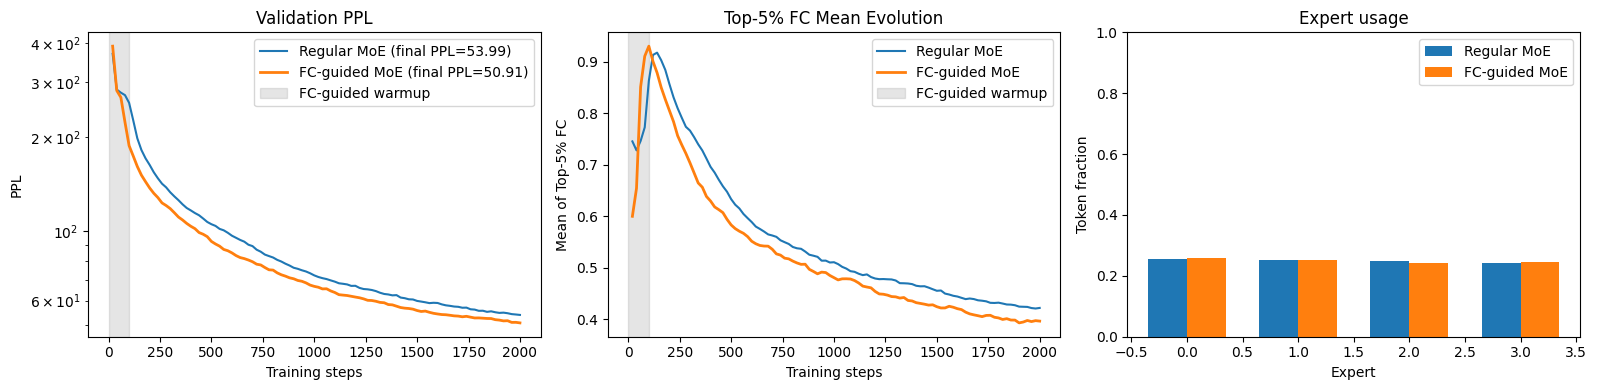

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

dense_final_loss, dense_final_ppl = evaluate_dense(dense_model, val_loader, cfg.eval_batches)
regular_final_loss, regular_final_ppl, regular_usage = evaluate_moe(regular_moe, val_loader, cfg.eval_batches)
fc_final_loss, fc_final_ppl, fc_usage = evaluate_moe(fc_guided_moe, val_loader, cfg.eval_batches)

print('\nFinal validation metrics')
print(f'Dense warmup      loss={dense_final_loss:.4f} ppl={dense_final_ppl:.2f}')
print(f'Regular MoE       loss={regular_final_loss:.4f} ppl={regular_final_ppl:.2f} usage={regular_usage}')
print(f'FC-guided MoE     loss={fc_final_loss:.4f} ppl={fc_final_ppl:.2f} usage={fc_usage}')
print(f'FC-guided delta vs regular MoE PPL: {fc_final_ppl - regular_final_ppl:.2f}')


def smooth_curve(points, factor=0.8):
    smoothed = []
    for p in points:
        if len(smoothed) == 0:
            smoothed.append(p)
        else:
            smoothed.append(smoothed[-1] * factor + p * (1 - factor))
    return smoothed

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ==========================================
# 0. 数据合并：不再使用 [1:] 切片，完整包含第0步数据
# ==========================================
# 完整合并 FC-guided 两个阶段的横坐标步数
fc_total_steps = list(dense_history['step']) + list(fc_guided_history['step'])
# 完整合并 FC-guided 两个阶段的 PPL 数据
fc_total_ppls = list(dense_history['val_ppl']) + list(fc_guided_history['val_ppl'])
# 完整合并 FC-guided 两个阶段的功能连接数据
fc_total_fcs = list(dense_history['fc_top_mean']) + list(fc_guided_history['fc_top_mean'])

# 提取 Regular MoE 的完整数据（包含第0步）
regular_steps = list(regular_history['step'])
regular_ppls = list(regular_history['val_ppl'])
regular_fcs = list(regular_history['fc_top_mean'])

# ==========================================
# 1. Validation PPL 曲线
# ==========================================
# Regular MoE 曲线
axes[0].plot(regular_steps, regular_ppls, label=f'Regular MoE (final PPL={regular_final_ppl:.2f})', color='tab:blue')
# FC-guided MoE 完整曲线（从第0步起笔，一条线画到底）
axes[0].plot(fc_total_steps, fc_total_ppls, label=f'FC-guided MoE (final PPL={fc_final_ppl:.2f})', color='tab:orange', linewidth=2)

axes[0].axvspan(0, cfg.warmup_steps, color='gray', alpha=0.2, label='FC-guided warmup')
axes[0].set_title('Validation PPL')
axes[0].set_xlabel('Training steps')
axes[0].set_ylabel('PPL')
axes[0].set_yscale('log')
axes[0].legend()

# ==========================================
# 2. FC Top-Mean 演化曲线
# ==========================================
# Regular MoE 曲线（包含第0步平滑）
axes[1].plot(regular_steps, smooth_curve(regular_fcs, 0.3), label='Regular MoE', color='tab:blue')
# FC-guided MoE 完整曲线：从第0步开始全局平滑，中间无任何断点
axes[1].plot(fc_total_steps, smooth_curve(fc_total_fcs, 0.3), label='FC-guided MoE', color='tab:orange', linewidth=2)

axes[1].axvspan(0, cfg.warmup_steps, color='gray', alpha=0.2, label='FC-guided warmup')
axes[1].set_title('Top-5% FC Mean Evolution')
axes[1].set_xlabel('Training steps')
axes[1].set_ylabel('Mean of Top-5% FC')
axes[1].legend()

# ==========================================
# 3. Expert Usage 条形图
# ==========================================
x = np.arange(cfg.num_experts)
width = 0.35
axes[2].bar(x - width / 2, regular_usage, width, label='Regular MoE')
axes[2].bar(x + width / 2, fc_usage, width, label='FC-guided MoE')
axes[2].set_title('Expert usage')
axes[2].set_xlabel('Expert')
axes[2].set_ylabel('Token fraction')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
# plt.savefig('./fig/moe_training_comparison.pdf', format='pdf')
plt.show()

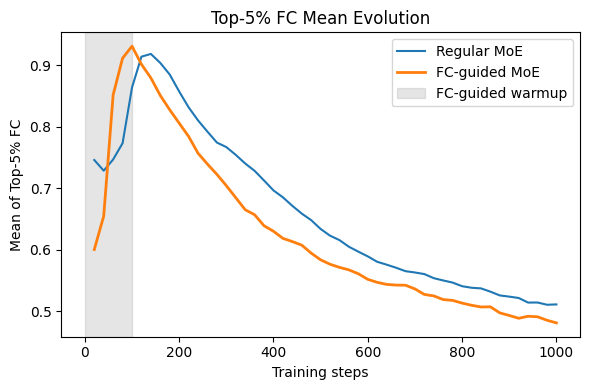

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42


def smooth_curve(points, factor=0.3):
    smoothed = []
    for p in points:
        if len(smoothed) == 0:
            smoothed.append(p)
        else:
            smoothed.append(smoothed[-1] * factor + p * (1 - factor))
    return smoothed


# 合并 FC-guided MoE 两个训练阶段
fc_total_steps = np.asarray(
    list(dense_history["step"]) +
    list(fc_guided_history["step"])
)

fc_total_fcs = np.asarray(
    list(dense_history["fc_top_mean"]) +
    list(fc_guided_history["fc_top_mean"])
)

# Regular MoE
regular_steps = np.asarray(regular_history["step"])
regular_fcs = np.asarray(regular_history["fc_top_mean"])

# 只保留前 1000 个训练步
max_step = 1000

regular_mask = regular_steps <= max_step
fc_mask = fc_total_steps <= max_step

# 分别对前 1000 步的数据进行平滑
regular_fcs_smooth = smooth_curve(
    regular_fcs[regular_mask],
    factor=0.3,
)

fc_fcs_smooth = smooth_curve(
    fc_total_fcs[fc_mask],
    factor=0.3,
)

# 绘图
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(
    regular_steps[regular_mask],
    regular_fcs_smooth,
    label="Regular MoE",
    color="tab:blue",
)

ax.plot(
    fc_total_steps[fc_mask],
    fc_fcs_smooth,
    label="FC-guided MoE",
    color="tab:orange",
    linewidth=2,
)

# 只在显示范围内绘制 warmup 阴影
ax.axvspan(
    0,
    min(cfg.warmup_steps, max_step),
    color="gray",
    alpha=0.2,
    label="FC-guided warmup",
)

ax.set_title("Top-5% FC Mean Evolution")
ax.set_xlabel("Training steps")
ax.set_ylabel("Mean of Top-5% FC")
# ax.set_xlim(0, max_step)
ax.legend()

plt.tight_layout()
plt.savefig("../fig/fc_first_1000_steps.pdf", format="pdf",
            bbox_inches="tight")
plt.show()

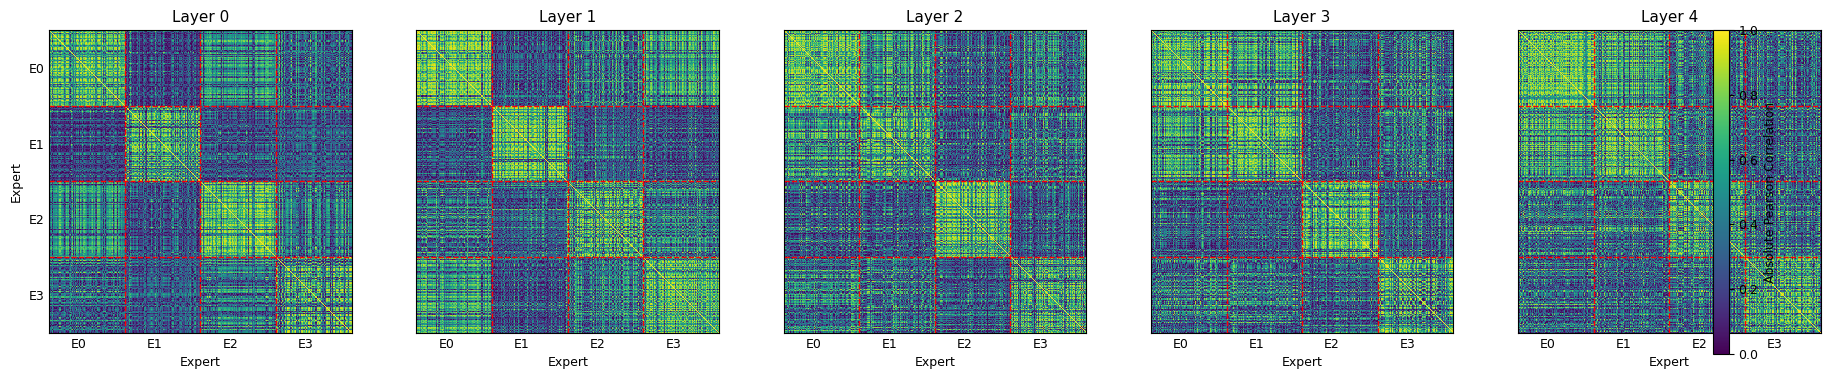

Figure saved to: ../fig/clustered_fc_all_layers.pdf


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import torch

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size'] = 9

def visualize_all_clustered_fc(output_path='clustered_fc_all_layers.pdf'):
    num_layers = min(5, len(fc_mats), len(clusters_by_layer))
    reordered_fc_mats = []
    cluster_sizes_by_layer = []

    for layer_idx in range(num_layers):
        fc_matrix = fc_mats[layer_idx].detach().cpu().abs().numpy()
        clusters = clusters_by_layer[layer_idx]

        reordered_indices = []
        for expert_group in clusters:
            if torch.is_tensor(expert_group):
                expert_group = expert_group.detach().cpu().tolist()
            else:
                expert_group = list(expert_group)
            reordered_indices.extend(expert_group)

        reordered_fc = fc_matrix[np.ix_(reordered_indices, reordered_indices)]
        reordered_fc_mats.append(reordered_fc)
        cluster_sizes_by_layer.append([len(expert_group) for expert_group in clusters])

    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 4.2), squeeze=False)
    axes = axes.ravel()

    for layer_idx, ax in enumerate(axes):
        reordered_fc = reordered_fc_mats[layer_idx]
        cluster_sizes = cluster_sizes_by_layer[layer_idx]

        image = ax.imshow(reordered_fc, cmap='viridis', interpolation='none', vmin=0, vmax=1, rasterized=True)

        boundaries = np.cumsum(cluster_sizes)
        starts = np.concatenate(([0], boundaries[:-1]))
        centers = starts + np.asarray(cluster_sizes) / 2 - 0.5

        for boundary in boundaries[:-1]:
            ax.axhline(boundary - 0.5, color='red', linestyle='--', linewidth=1.0)
            ax.axvline(boundary - 0.5, color='red', linestyle='--', linewidth=1.0)

        labels = [f'E{i}' for i in range(len(cluster_sizes))]
        ax.set_title(f'Layer {layer_idx}', fontsize=11)
        ax.set_xlabel('Expert')
        if layer_idx == 0:
            ax.set_ylabel('Expert')

        ax.set_xticks(centers)
        ax.set_xticklabels(labels, rotation=0, ha='right')
        ax.set_yticks(centers)
        ax.set_yticklabels(labels if layer_idx == 0 else [])
        ax.tick_params(axis='both', length=0)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

    cbar = fig.colorbar(image, ax=axes.tolist(), fraction=0.018, pad=0.015)
    cbar.set_label('Absolute Pearson Correlation')

    fig.subplots_adjust(left=0.05, right=0.94, bottom=0.16, top=0.88, wspace=0.18)
    fig.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    print(f'Figure saved to: {output_path}')

visualize_all_clustered_fc(output_path='../fig/clustered_fc_all_layers.pdf')

## 9. 专家处理 Token 的语义分析

开始计算 Regular MoE 全层指标...
Layer 0 处理完毕.
Layer 1 处理完毕.
Layer 2 处理完毕.
Layer 3 处理完毕.
Layer 4 处理完毕.

开始计算 FC-guided MoE 全层指标...
Layer 0 处理完毕.
Layer 1 处理完毕.
Layer 2 处理完毕.
Layer 3 处理完毕.
Layer 4 处理完毕.


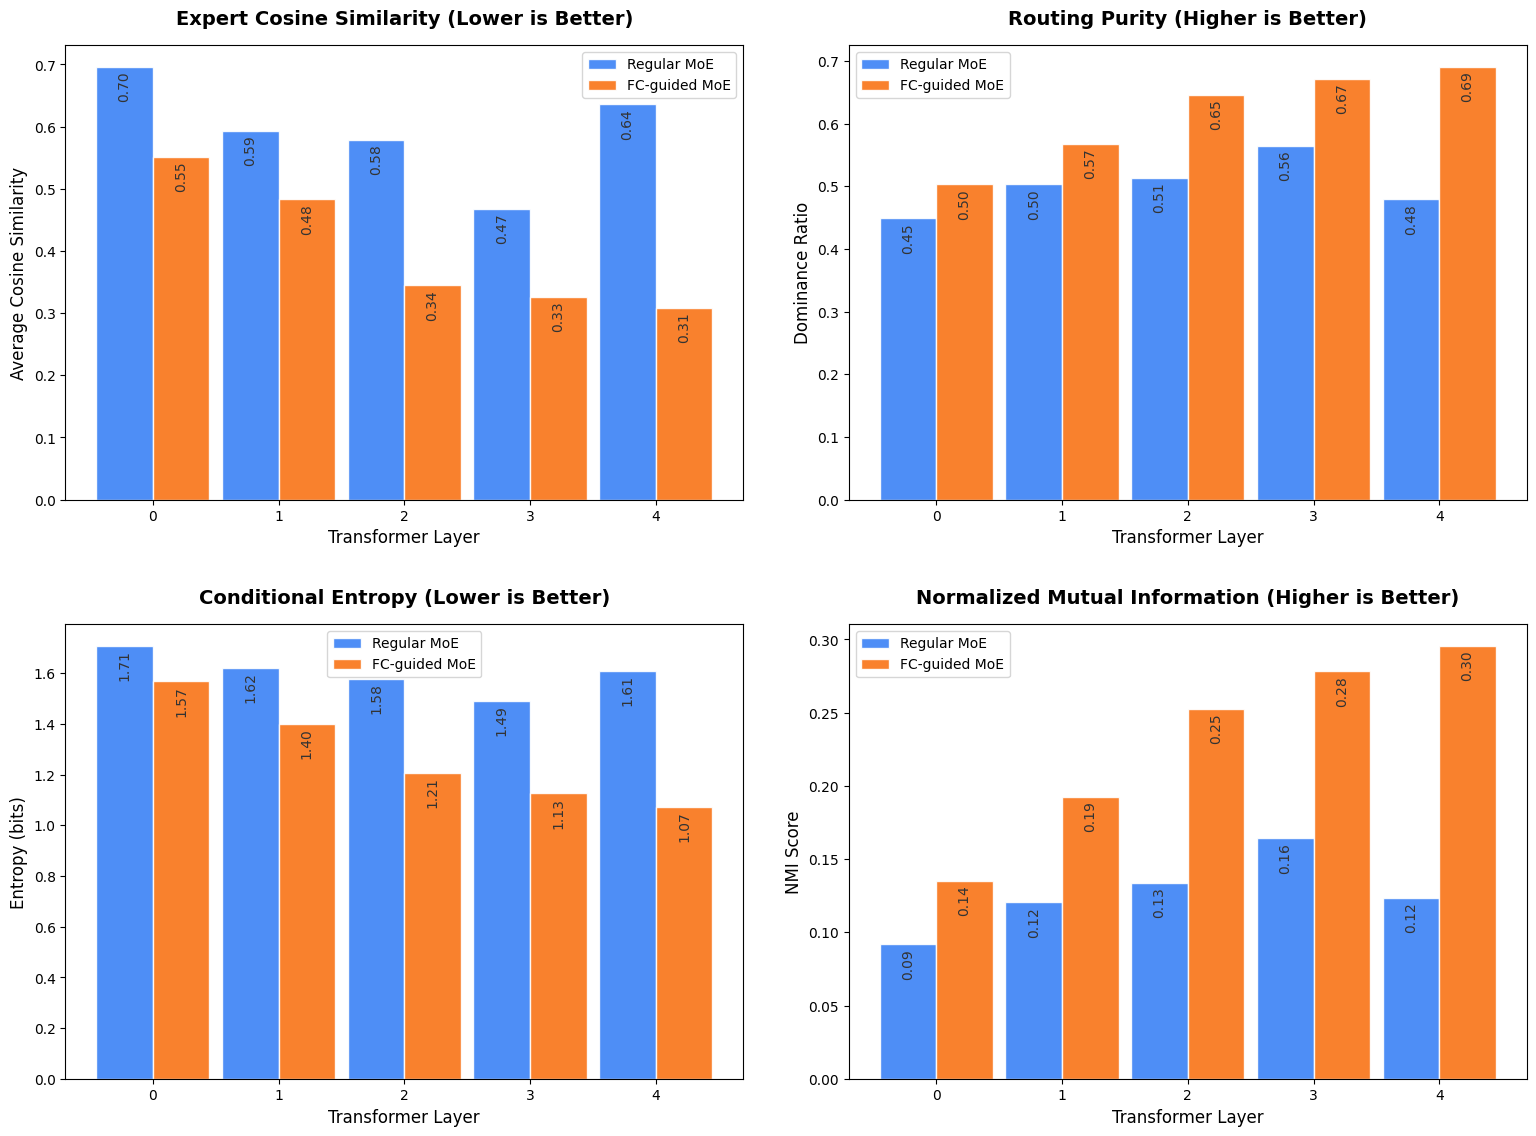

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import torch
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import normalized_mutual_info_score
from scipy.stats import entropy

def compute_all_specialization_metrics(model, loader, itos, n_layers, max_batches=15):
    """
    遍历模型所有层，计算专家特化的四大指标：
    1. Cosine Similarity (余弦相似度)
    2. Routing Purity (路由支配纯度)
    3. Conditional Entropy (分配条件熵)
    4. Normalized Mutual Information (NMI)
    """
    metrics = {
        'Cosine_Similarity': [],
        'Purity': [],
        'Conditional_Entropy': [],
        'NMI': []
    }
    
    model.eval()
    for layer_idx in range(n_layers):
        routing_indices = []
        all_tokens = []
        
        # 1. 挂载钩子
        def hook_fn(module, input, output):
            out_tensor = output[0] if isinstance(output, tuple) else output
            top_idx = torch.argmax(out_tensor, dim=-1)
            routing_indices.append(top_idx.detach().cpu().numpy())

        handle = model.blocks[layer_idx].moe.router.register_forward_hook(hook_fn)
        
        # 2. 提取当前层数据
        with torch.no_grad():
            for i, (x, y) in enumerate(loader):
                if i >= max_batches:
                    break
                x_flat = x.view(-1).cpu().numpy()
                all_tokens.extend([itos.get(tok, '<unk>') for tok in x_flat])
                x = x.to(device)
                _ = model(x)
                
        handle.remove()
        
        # 3. 数据清洗与词性标注
        all_routing = np.concatenate(routing_indices)
        valid_data = [(tok, exp) for tok, exp in zip(all_tokens, all_routing) if tok not in ['<pad>', '<unk>']]
        tokens = [tok for tok, exp in valid_data]
        routing = [exp for tok, exp in valid_data]
        
        pos_tags = [tag for word, tag in nltk.pos_tag(tokens)]
        df = pd.DataFrame({'POS': pos_tags, 'Expert': routing})
        crosstab = pd.crosstab(df['POS'], df['Expert'])
        
        # 4. 计算指标
        # 余弦相似度
        expert_vectors = crosstab.T.values
        if len(expert_vectors) > 1:
            sim_matrix = cosine_similarity(expert_vectors)
            upper_tri_indices = np.triu_indices(sim_matrix.shape[0], k=1)
            avg_cosine_sim = np.mean(sim_matrix[upper_tri_indices])
        else:
            avg_cosine_sim = 1.0
            
        # 路由纯度
        total_tokens = crosstab.values.sum()
        max_dominance_sum = crosstab.max(axis=1).sum()
        purity = max_dominance_sum / total_tokens if total_tokens > 0 else 0
        
        # 条件熵
        cond_entropy = 0.0
        if total_tokens > 0:
            for pos in crosstab.index:
                row_counts = crosstab.loc[pos].values
                pos_prob = row_counts.sum() / total_tokens
                row_entropy = entropy(row_counts, base=2)
                cond_entropy += pos_prob * row_entropy
                
        # 归一化互信息 (NMI)
        nmi = normalized_mutual_info_score(pos_tags, routing)
                
        metrics['Cosine_Similarity'].append(avg_cosine_sim)
        metrics['Purity'].append(purity)
        metrics['Conditional_Entropy'].append(cond_entropy)
        metrics['NMI'].append(nmi)
        
        print(f"Layer {layer_idx} 处理完毕.")
        
    return metrics

# ================= 1. 执行计算 =================
print("开始计算 Regular MoE 全层指标...")
reg_metrics_all = compute_all_specialization_metrics(regular_moe, val_loader, itos, cfg.n_layers, max_batches=20)

print("\n开始计算 FC-guided MoE 全层指标...")
fc_metrics_all = compute_all_specialization_metrics(fc_guided_moe, val_loader, itos, cfg.n_layers, max_batches=20)


# ================= 2. 绘制 2x2 矩阵分组柱状图 =================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
x = np.arange(cfg.n_layers)
width = 0.45  # 柱子宽度

# 使用原始代码中定义的配色方案
color_reg = "#3B82F6" # 蓝色
color_fc = "#F97316"  # 橙色

def plot_grouped_bar(ax, metric_key, title, ylabel, is_higher_better=True):
    reg_vals = reg_metrics_all[metric_key]
    fc_vals = fc_metrics_all[metric_key]
    
    rects1 = ax.bar(x - width/2, reg_vals, width, label='Regular MoE', color=color_reg, alpha=0.9, edgecolor='white')
    rects2 = ax.bar(x + width/2, fc_vals, width, label='FC-guided MoE', color=color_fc, alpha=0.9, edgecolor='white')
    
    # 动态标题与轴标签
    ax.set_title(title, fontsize=14, pad=15, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Transformer Layer', fontsize=12)
    ax.set_xticks(x)
    
    # 美化边框与网格
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend()
    
    # 在柱子上添加具体数值文本，增加直观度
    for rect in rects1 + rects2:
        height = rect.get_height()
        # 对于数值极小的熵或 NMI，增加精度
        text_val = f'{height:.2f}'
        ax.annotate(text_val,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, -25), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, color='#333333', rotation=90)

# 绘制四个子图
plot_grouped_bar(axes[0, 0], 'Cosine_Similarity', 'Expert Cosine Similarity (Lower is Better)', 'Average Cosine Similarity')
plot_grouped_bar(axes[0, 1], 'Purity', 'Routing Purity (Higher is Better)', 'Dominance Ratio')
plot_grouped_bar(axes[1, 0], 'Conditional_Entropy', 'Conditional Entropy (Lower is Better)', 'Entropy (bits)')
plot_grouped_bar(axes[1, 1], 'NMI', 'Normalized Mutual Information (Higher is Better)', 'NMI Score')

plt.tight_layout(pad=3.0)
plt.savefig('../fig/expert_specialization_metrics.pdf', format='pdf')
plt.show()